# 08 — Caching & Persistence

**Concept:** Caching stores a materialized DataFrame in executor memory (and optionally disk) so subsequent actions can skip recomputation. The decision of *when* to cache, *which storage level* to use, and *when to unpersist* directly determines whether caching speeds a job up or wastes memory that execution needs for shuffles and joins. Getting this wrong is one of the most common sources of unexplained slowdowns in production Spark pipelines.

**Core interview question:** *"When should you cache a DataFrame? What are the trade-offs between storage levels?"*

## What you will observe
1. **Storage levels in practice** — persist with `MEMORY_ONLY`, `MEMORY_AND_DISK`, `MEMORY_ONLY_SER`, and `DISK_ONLY`; read `storageLevel` from the live DataFrame object.
2. **The diamond pattern** — one DataFrame forks into three downstream aggregations; timing with and without cache proves when caching pays off.
3. **When caching hurts** — caching a DataFrame that is used only once adds materialization cost and wastes storage pool space.
4. **Cache invalidation** — a `.filter()` on a cached DataFrame produces a new, *uncached* DataFrame; the original cache remains but the transformation result is not cached.
5. **Checkpoint** — breaks RDD lineage so Spark does not need to replay a long chain of transformations; materially different from cache in durability, lineage semantics, and use cases.
6. **Broadcast variables vs cached DataFrames** — broadcast pushes data to every executor for use inside UDFs or joins; cache stores data partitioned across executors for reuse in DataFrame operations.

## Caching fundamentals

### `cache()` vs `persist()`

```python
df.cache()                                      # shorthand — see PySpark note below
df.persist(StorageLevel.MEMORY_ONLY)            # explicit serialized level
df.persist(StorageLevel.MEMORY_AND_DISK_DESER)  # explicit deserialized level
df.persist(StorageLevel(False, True, False, False, 1))  # constructor form
```

> **PySpark vs Scala API — two important differences:**
>
> 1. **`cache()` default:** In Scala `cache()` = `MEMORY_ONLY`. In PySpark, `df.cache()` calls the JVM directly and resolves to **deserialized** Tungsten format (`MEMORY_AND_DISK` with `deserialized=True`).
>
> 2. **`_SER` constants missing:** Scala has `MEMORY_ONLY_SER` and `MEMORY_AND_DISK_SER` as named constants. **PySpark does not.** In PySpark, `MEMORY_ONLY` is already serialized (`deserialized=False`). Use `StorageLevel(useDisk, useMemory, useOffHeap, deserialized, replication)` to construct any level not in the predefined set.

### Named constants available in PySpark

| Constant | useDisk | useMemory | deserialized | On eviction | Notes |
|---|---|---|---|---|---|
| `MEMORY_ONLY` | No | Yes | **No** (serialized) | Block **dropped** | ≈ Scala's `MEMORY_ONLY_SER` |
| `MEMORY_AND_DISK` | Yes | Yes | **No** (serialized) | Block **spills to disk** | |
| `MEMORY_AND_DISK_DESER` | Yes | Yes | **Yes** (Tungsten) | Spills to disk | ≈ `cache()` behaviour |
| `DISK_ONLY` | Yes | No | No | N/A | Never in memory |
| `MEMORY_ONLY_2` | No | Yes | No | Block dropped | 2 replicas |
| `MEMORY_AND_DISK_2` | Yes | Yes | No | Spills to disk | 2 replicas |
| `OFF_HEAP` | Yes | Yes | No | — | Requires off-heap config |

> **`deserialized=True`** (Tungsten/Java objects on heap): fastest read, higher GC pressure.
> **`deserialized=False`** (serialized byte arrays): ~20–50% smaller footprint, CPU cost to decode on read.

### Key decision rules

```
DataFrame used more than once in the same application?
  YES — cache it
  NO  — do NOT cache — the materialization cost outweighs the benefit

Want the fastest reads and GC is not a bottleneck?
  → MEMORY_AND_DISK_DESER  (deserialized Tungsten — same as cache())

DataFrame is large relative to storage pool, or GC Time is high?
  → MEMORY_ONLY or MEMORY_AND_DISK  (serialized — compact byte arrays)

Need fault tolerance on preemptible/spot VMs?
  → _2 suffix (replicated) or checkpoint (durable external storage)
```

In [1]:
import sys
import os
import random
import time
import tempfile
from pathlib import Path

sys.path.append(str(Path().absolute().parent))

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ.setdefault("HADOOP_HOME", r"C:\hadoop")
os.environ["PATH"] = r"C:\hadoop\bin" + os.pathsep + os.environ.get("PATH", "")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, DoubleType
from pyspark import StorageLevel

spark = (
    SparkSession.builder
    .master("local[4]")
    .appName("08-caching-and-persistence")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.memory.fraction", "0.6")
    .config("spark.memory.storageFraction", "0.5")
    .config("spark.python.worker.reuse", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

print(f"Spark {spark.version}  —  UI: http://localhost:4040")
print(f"memory.fraction       : {spark.conf.get('spark.memory.fraction')}")
print(f"memory.storageFraction: {spark.conf.get('spark.memory.storageFraction')}")
print(f"shuffle.partitions    : {spark.conf.get('spark.sql.shuffle.partitions')}")

Spark 3.5.8  —  UI: http://localhost:4040
memory.fraction       : 0.6
memory.storageFraction: 0.5
shuffle.partitions    : 200


In [2]:
random.seed(42)

N = 500_000
CATEGORIES = ["electronics", "clothing", "food", "furniture", "sports", "books", "beauty"]

orders_data = [
    (
        i,
        random.randint(1, 10_000),
        random.randint(1, 500),
        random.choice(["US", "DE", "GB", "FR", "JP", "BR", "IN", "CA", "AU", "MX"]),
        round(random.uniform(1.0, 5000.0), 2),
        random.randint(1, 100),
        f"notes_{random.randint(1, 1000)}",
    )
    for i in range(1, N + 1)
]

orders_schema = StructType([
    StructField("order_id",    IntegerType(), False),
    StructField("customer_id", IntegerType(), True),
    StructField("product_id",  IntegerType(), True),
    StructField("region",      StringType(),  True),
    StructField("amount",      DoubleType(),  True),
    StructField("quantity",    IntegerType(), True),
    StructField("notes",       StringType(),  True),
])

orders = spark.createDataFrame(orders_data, schema=orders_schema)

products = spark.createDataFrame(
    [
        (i, f"product_{i}", CATEGORIES[i % len(CATEGORIES)],
         round(random.uniform(5.0, 500.0), 2))
        for i in range(1, 501)
    ],
    ["product_id", "product_name", "category", "list_price"]
)

print(f"orders   : {N:,} rows, {len(orders.columns)} columns")
print(f"products : {products.count()} rows, categories: {CATEGORIES}")

orders   : 500,000 rows, 7 columns
products : 500 rows, categories: ['electronics', 'clothing', 'food', 'furniture', 'sports', 'books', 'beauty']


## 1. Storage levels — what Spark actually stores

When you call `.cache()` or `.persist(level)`, Spark does **not** immediately copy any data. Like all transformations, it is lazy. The cache is populated when the first *action* after the `.cache()` call is executed.

After materialization you can inspect what Spark stored with `df.storageLevel`. The Spark UI Storage tab shows each cached entry: size in memory, size on disk, number of cached partitions, and the fraction that fit in the storage pool.

**Key properties of the `StorageLevel` object:**

| Attribute | Meaning |
|---|---|
| `useMemory` | True if blocks are stored in executor JVM heap |
| `useDisk` | True if overflow blocks go to executor local disk |
| `useOffHeap` | True if using Tungsten off-heap storage |
| `deserialized` | True = Java objects (fast read, more GC). False = byte array (compact, CPU cost to read) |
| `replication` | Number of replicas across executors (default 1) |

In [4]:
# ── Persist with each storage level and inspect the resulting storageLevel ──
# PySpark note: MEMORY_ONLY_SER / MEMORY_AND_DISK_SER are NOT named constants in PySpark.
# MEMORY_ONLY in PySpark is already serialized (deserialized=False). Use the constructor
# StorageLevel(useDisk, useMemory, useOffHeap, deserialized, replication) for custom levels.

# Level 1: cache() — calls the JVM directly; resolves to deserialized Tungsten format
orders_cached = orders.cache()
orders_cached.count()  # materialize
sl = orders_cached.storageLevel
print(f"cache()              → useMem={sl.useMemory}  useDisk={sl.useDisk}  deser={sl.deserialized}  rep={sl.replication}")
print(f"                       {orders_cached.storageLevel}")
orders_cached.unpersist()
print()

# Level 2: MEMORY_ONLY — serialized byte arrays on heap, dropped on eviction
orders_mem_only = orders.persist(StorageLevel.MEMORY_ONLY)
orders_mem_only.count()
sl = orders_mem_only.storageLevel
print(f"MEMORY_ONLY          → useMem={sl.useMemory}  useDisk={sl.useDisk}  deser={sl.deserialized}  rep={sl.replication}")
print(f"                       {orders_mem_only.storageLevel}")
print("  ↳ deserialized=False means serialized byte arrays (compact, CPU cost to read)")
print("  ↳ This is what Scala calls MEMORY_ONLY_SER — the PySpark default for MEMORY_ONLY")
orders_mem_only.unpersist()
print()

# Level 3: MEMORY_AND_DISK_DESER — deserialized Tungsten objects on heap, overflow to disk
#   This is the explicitly deserialized variant — fastest read, highest GC pressure
orders_deser = orders.persist(StorageLevel.MEMORY_AND_DISK_DESER)
orders_deser.count()
sl = orders_deser.storageLevel
print(f"MEMORY_AND_DISK_DESER → useMem={sl.useMemory}  useDisk={sl.useDisk}  deser={sl.deserialized}  rep={sl.replication}")
print(f"                        {orders_deser.storageLevel}")
print("  ↳ deserialized=True means Java/Tungsten objects on heap (fast read, more GC)")
print("  ↳ Equivalent to what cache() resolves to internally")
orders_deser.unpersist()
print()

# Level 4: DISK_ONLY — never in memory (for extremely large DataFrames)
orders_disk = orders.persist(StorageLevel.DISK_ONLY)
orders_disk.count()
sl = orders_disk.storageLevel
print(f"DISK_ONLY            → useMem={sl.useMemory}  useDisk={sl.useDisk}  deser={sl.deserialized}  rep={sl.replication}")
print(f"                       {orders_disk.storageLevel}")
orders_disk.unpersist()
print()

# Level 5: MEMORY_AND_DISK_2 — replicated across 2 executors (fault tolerant)
orders_rep2 = orders.persist(StorageLevel.MEMORY_AND_DISK_2)
orders_rep2.count()
sl = orders_rep2.storageLevel
print(f"MEMORY_AND_DISK_2    → useMem={sl.useMemory}  useDisk={sl.useDisk}  deser={sl.deserialized}  rep={sl.replication}")
print(f"                       {orders_rep2.storageLevel}")
orders_rep2.unpersist()
print()

# Constructor form — build any level explicitly
# StorageLevel(useDisk, useMemory, useOffHeap, deserialized, replication)
custom = StorageLevel(False, True, False, False, 1)  # = MEMORY_ONLY
print(f"Constructor equivalent of MEMORY_ONLY_SER: {custom}")
print("(Identical to StorageLevel.MEMORY_ONLY — useful when you need a level not in the predefined set)")
print()
print("All levels produce InMemoryTableScan in explain() — the storage level is transparent to the planner.")
orders_mem_disk2 = orders.cache()
orders_mem_disk2.count()
orders_mem_disk2.explain(mode="simple")

cache()              → useMem=True  useDisk=True  deser=True  rep=1
                       Disk Memory Deserialized 1x Replicated

MEMORY_ONLY          → useMem=True  useDisk=False  deser=False  rep=1
                       Memory Serialized 1x Replicated
  ↳ deserialized=False means serialized byte arrays (compact, CPU cost to read)
  ↳ This is what Scala calls MEMORY_ONLY_SER — the PySpark default for MEMORY_ONLY

MEMORY_AND_DISK_DESER → useMem=True  useDisk=True  deser=True  rep=1
                        Disk Memory Deserialized 1x Replicated
  ↳ deserialized=True means Java/Tungsten objects on heap (fast read, more GC)
  ↳ Equivalent to what cache() resolves to internally

DISK_ONLY            → useMem=False  useDisk=True  deser=False  rep=1
                       Disk Serialized 1x Replicated

MEMORY_AND_DISK_2    → useMem=True  useDisk=True  deser=False  rep=2
                       Disk Memory Serialized 2x Replicated

Constructor equivalent of MEMORY_ONLY_SER: Memory Serialized

### What to observe

**`storageLevel` output:** the five boolean fields tell you exactly where data lives:
```
Disk Memory Deserialized 1x Replicated
│    │      │             └─ replication factor
│    │      └─ True = Tungsten/Java objects on heap (fast read, more GC)
│    │         False = serialized byte arrays (compact, CPU cost to read)
│    └─ True = blocks live in executor JVM heap
└─ True = overflow blocks written to local disk
```

**`cache()` vs `persist(StorageLevel.MEMORY_AND_DISK)`:**
Both use memory+disk, but `cache()` resolves to `deserialized=True` (Tungsten format) while
`persist(StorageLevel.MEMORY_AND_DISK)` is `deserialized=False` (serialized byte arrays).
This is a PySpark subtlety — the Python `MEMORY_AND_DISK` constant and what `cache()` actually stores are different.

**PySpark serialization landscape:**
- `MEMORY_ONLY` in PySpark → serialized (`deserialized=False`) — equivalent to Scala's `MEMORY_ONLY_SER`
- `MEMORY_AND_DISK_DESER` in PySpark → deserialized (`deserialized=True`) — equivalent to what `cache()` stores
- `MEMORY_ONLY_SER` / `MEMORY_AND_DISK_SER` → **not named constants** in PySpark; use the constructor if needed

**When `deserialized=True` (Tungsten objects):**
- Blocks are stored as UnsafeRow binary format — no extra deserialization step on read
- More GC pressure because objects live on the GC-managed heap
- Choose when read latency is critical and GC Time is low (< 5% in task metrics)

**When `deserialized=False` (serialized byte arrays):**
- Blocks stored compactly — 20–50% smaller heap footprint than deserialized equivalent
- CPU cost to decode on every read
- Choose when the DataFrame is large relative to the storage pool or GC Time is high

**`DISK_ONLY`:** rarely used in practice. Every read requires a full decode from disk.
Only use when the DataFrame is so large that even a fraction in memory would evict other critical data.

**`_2` suffix (replicated):** requires two healthy executors. Protects against executor failure
without recomputing from lineage. Costs 2× memory. Useful on preemptible/spot VMs.

**Spark UI — Storage tab:** open `http://localhost:4040/storage` after `.count()`. Each entry shows:
- `RDD Name` — the DataFrame's cache key
- `Storage Level` — the level string (e.g. "Disk Memory Deserialized 1x Replicated")
- `Cached Partitions / Total Partitions` — if `Cached < Total`, blocks were evicted or didn't fit
- `Fraction Cached` — `< 1.0` means the cache is incomplete
- `Size in Memory / Size on Disk` — non-zero disk means blocks overflowed

## 2. When does the cache actually materialise?

`cache()` is **lazy** — like every transformation, it only marks the DataFrame. No data is copied
into the storage pool until the first *action* after the call. The first action materialises the
cache **and** performs the action at the same time. There is no requirement for an explicit `.count()`.

```
df.cache()                      ← lazy: marks df for caching, nothing runs
df.groupBy(...).collect()       ← FIRST action: materialises cache + runs aggregation simultaneously
df.groupBy(...).collect()       ← SECOND action: reads from cache, aggregation skipped
```

### Why `.count()` is used deliberately (not because it's required)

| Reason | Explanation |
|---|---|
| **Clean benchmarks** | Separates the materialisation job from the downstream read jobs so timing is uncontaminated |
| **Clean Spark UI** | Without it, the first downstream job's DAG mixes full source lineage with the cache write — harder to read |
| **Fail fast** | Forces a full scan of the source immediately so data issues (schema mismatches, missing partitions) surface before the real work begins |

### What about a write as the first action?

```python
wide_df.cache()
wide_df.write.parquet("silver/")    # first action → materialises cache + writes simultaneously
wide_df.write.parquet("archive/")   # second action → reads from cache, no recompute
```

Writing to two destinations from the same DataFrame is a valid diamond pattern — the cache pays
off on the second write. Caching before a *single* write is pointless: the cache is populated
and then immediately abandoned.

In [ ]:
# Prove that cache() is lazy and the first action materialises it
df = orders.filter(F.col("amount") > 100)

df.cache()  # lazy — nothing has run yet

print(f"After cache() call         → storageLevel: {df.storageLevel}")
print("  ↳ StorageLevelNone: the cache is NOT populated yet")
print()

# ── Scenario A: first action is groupBy (no explicit count()) ─────────────────
# The groupBy materialises the cache AND computes the aggregation in the same job.
r1 = df.groupBy("region").agg(F.count("*").alias("cnt")).collect()

print(f"After first groupBy.collect() → storageLevel: {df.storageLevel}")
print("  ↳ Cache is now populated — first action triggered materialisation")
print()

# Second action reads from cache — no recompute of the filter
r2 = df.groupBy("product_id").agg(F.sum("amount").alias("rev")).collect()
print(f"After second groupBy.collect() → storageLevel: {df.storageLevel}")
print("  ↳ Still cached — second action read from storage pool")
print()

df.unpersist()

# ── Scenario B: explicit count() first (clean separation) ─────────────────────
df2 = orders.filter(F.col("amount") > 100).cache()

print(f"Before count()  → storageLevel: {df2.storageLevel}")  # None

df2.count()  # materialise only — no computation mixed in

print(f"After count()   → storageLevel: {df2.storageLevel}")  # populated
print()
print("Scenario B advantage: subsequent timing measurements start from a warm cache.")
print("Scenario A advantage: one fewer job when you don't need clean benchmarking.")

df2.unpersist()

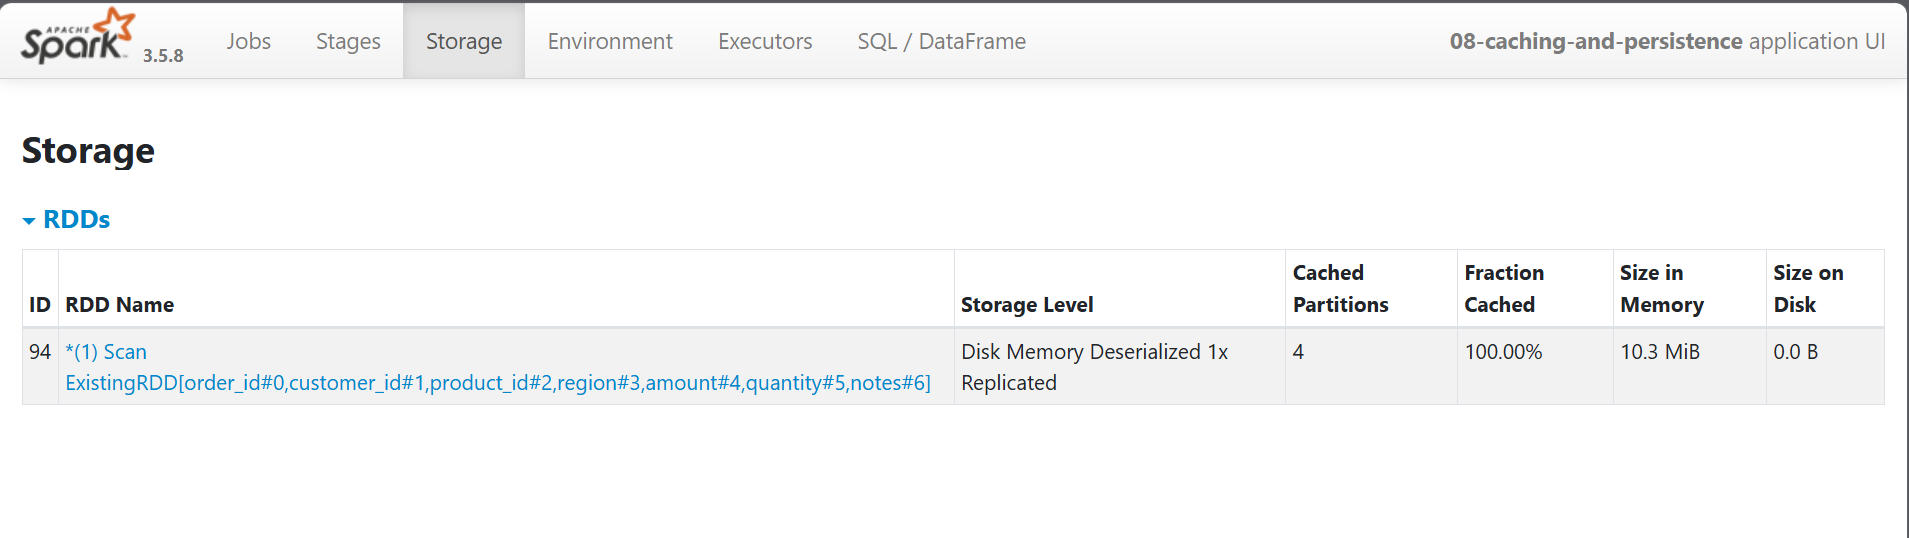

## 2. When caching helps — the diamond pattern

The canonical cache use case is a **fork**: one DataFrame feeds two or more downstream operations within the same Spark application. Without a cache, Spark recomputes the shared DataFrame from scratch for each downstream action.

```
                 ┌─────────────────────────────────────────────────────┐
                 │  wide_df  (filter + join + 3 withColumn transforms) │ ← expensive to compute
                 └──────────────────┬───────────────────┬──────────────┘
                                    │                   │             │
                         groupBy("region")   groupBy("tier")   groupBy("category")
                                    │                   │             │
                                   agg1                agg2          agg3
```

**Without cache:** Spark traces the lineage of each action back to the source and re-runs the filter, join, and `withColumn` transformations three times.

**With cache:** the first action materializes `wide_df` into the storage pool. The second and third actions read from `InMemoryTableScan` — the join and transforms do not re-run.

**Rule of thumb:** cache when `number_of_downstream_actions >= 2` and the shared DataFrame involves at least one shuffle (join, groupBy, orderBy).

In [5]:
# Build a moderately expensive shared DataFrame:
# filter + broadcast join + 3 derived columns
wide_df = (
    orders
    .filter(F.col("amount") > 50.0)
    .join(F.broadcast(products), "product_id")
    .withColumn("discount",
        F.when(F.col("region").isin("US", "GB"), F.col("amount") * 0.10)
         .otherwise(0.0))
    .withColumn("net_amount", F.col("amount") - F.col("discount"))
    .withColumn("revenue_tier",
        F.when(F.col("net_amount") > 3000, "premium")
         .when(F.col("net_amount") > 1000, "standard")
         .otherwise("basic"))
)

# ── WITHOUT cache — wide_df is recomputed on each action ──────────────────
t0 = time.time()
r1 = wide_df.groupBy("region").agg(
    F.sum("net_amount").alias("regional_revenue")).collect()
r2 = wide_df.groupBy("revenue_tier").agg(
    F.count("*").alias("tier_count")).collect()
r3 = wide_df.groupBy("category").agg(
    F.avg("net_amount").alias("avg_net")).collect()
no_cache_elapsed = time.time() - t0

print(f"Without cache: {no_cache_elapsed:.2f}s — wide_df rebuilt from source 3 times")
print()

# ── WITH cache — wide_df materialized once, reused ──────────────────────────
wide_df.cache()
wide_df.count()    # warm the cache — this pays the materialization cost once
print(f"Cache materialized. storageLevel: {wide_df.storageLevel}")
print()

t0 = time.time()
r1 = wide_df.groupBy("region").agg(
    F.sum("net_amount").alias("regional_revenue")).collect()
r2 = wide_df.groupBy("revenue_tier").agg(
    F.count("*").alias("tier_count")).collect()
r3 = wide_df.groupBy("category").agg(
    F.avg("net_amount").alias("avg_net")).collect()
cache_elapsed = time.time() - t0

print(f"With cache: {cache_elapsed:.2f}s — wide_df read from storage pool 3 times")
print(f"Speedup   : {no_cache_elapsed / cache_elapsed:.1f}x")
print()

# Explain: the cached plan shows InMemoryTableScan instead of the join tree
print("=== Plan WITH cache ===")
print("Source: InMemoryTableScan (reads from storage pool, skips the join)")
wide_df.groupBy("region").agg(F.sum("net_amount").alias("r")).explain(mode="simple")

Without cache: 13.27s — wide_df rebuilt from source 3 times

Cache materialized. storageLevel: Disk Memory Deserialized 1x Replicated

With cache: 1.47s — wide_df read from storage pool 3 times
Speedup   : 9.0x

=== Plan WITH cache ===
Source: InMemoryTableScan (reads from storage pool, skips the join)
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[region#3], functions=[sum(net_amount#1934)])
   +- Exchange hashpartitioning(region#3, 200), ENSURE_REQUIREMENTS, [plan_id=1170]
      +- HashAggregate(keys=[region#3], functions=[partial_sum(net_amount#1934)])
         +- InMemoryTableScan [region#3, net_amount#1934]
               +- InMemoryRelation [product_id#2, order_id#0, customer_id#1, region#3, amount#4, quantity#5, notes#6, product_name#15, category#16, list_price#17, discount#1922, net_amount#1934, revenue_tier#1947], StorageLevel(disk, memory, deserialized, 1 replicas)
                     +- AdaptiveSparkPlan isFinalPlan=true
                     

### What to observe

**Runtime:** on the second and third aggregations the cached path reads from `InMemoryTableScan` — the join and `withColumn` transforms do not re-execute. The speedup scales with how expensive the shared computation is. A 2–5× speedup is typical for a join + several transforms; a 10–20× speedup is possible for pipelines with complex aggregations feeding many outputs.

**`explain()` with cache:**
```
HashAggregate(final)
+- Exchange hashpartitioning(region, 200)
     +- HashAggregate(partial)
          +- InMemoryTableScan [region, net_amount]   ← reads from storage pool
               +- InMemoryRelation [order_id, customer_id, ...] StorageLevel(disk, memory, ...)
```
Compare to the **uncached plan** which shows:
```
HashAggregate(final)
+- Exchange hashpartitioning(region, 200)
     +- HashAggregate(partial)
          +- Project [region, net_amount]
               +- BroadcastHashJoin [product_id]    ← re-runs the join
                    +- Filter (amount > 50.0)       ← re-runs the filter
                         +- Scan ExistingRDD
               +- BroadcastExchange                 ← re-broadcasts products
```

**Spark UI — Stages tab:**
- Without cache: each of the 3 aggregations triggers a job that includes a stage for the broadcast join
- With cache: the warm-up `.count()` job includes the join stage; the 3 aggregation jobs each skip it

**Spark UI — SQL tab:**
- Look for the `InMemoryRelation` node in the post-cache plan — clicking it shows the cached size and level

## 3. When caching hurts

Caching is not free. The cost has two components:

**1. Materialization cost:** the first action after `.cache()` must compute AND store the data. For a DataFrame used only once downstream, you pay this extra cost without any subsequent benefit.

**2. Storage pool pressure:** cached data occupies the storage pool inside the executor's Spark managed memory. A cache that fills the storage pool reduces the space available to execution (shuffles, sorts, aggregations). Under the unified memory model, execution will evict cache blocks to reclaim space — but if the evicted data is needed again, Spark recomputes it from lineage, producing the worst of both worlds.

**The "cache everything" anti-pattern:**
```python
# ANTI-PATTERN — caching single-use DataFrames
df1 = raw.filter(...).cache()          # used only once below
result = df1.groupBy(...).agg(...).write.parquet(...)
df1.unpersist()                        # programmer remembers to clean up — but still paid the cost
```

**Rule:** only cache when `downstream_actions >= 2`. Count the actions; don't guess.

In [7]:
# Demonstrate the cost of caching a single-use DataFrame

# ── Approach A: direct — no cache, single action ─────────────────────────────
t0 = time.time()
result_direct = (
    orders
    .filter(F.col("region") == "US")
    .groupBy("product_id")
    .agg(F.sum("amount").alias("us_revenue"))
    .orderBy("us_revenue", ascending=False)
)
count_direct = result_direct.count()  # single action
direct_elapsed = time.time() - t0
print(f"Direct (no cache): {direct_elapsed:.2f}s   rows={count_direct:,}")

# ── Approach B: cache + single action + unpersist ────────────────────────────
t0 = time.time()
us_orders = orders.filter(F.col("region") == "US").cache()
us_orders.count()           # materialize cache  ← EXTRA action that was not in Approach A
result_cached = (
    us_orders
    .groupBy("product_id")
    .agg(F.sum("amount").alias("us_revenue"))
    .orderBy("us_revenue", ascending=False)
)
count_cached = result_cached.count()  # the "useful" action
cache_elapsed = time.time() - t0
us_orders.unpersist()

print(f"Cache+single use: {cache_elapsed:.2f}s   rows={count_cached:,}")
print(f"Overhead         : {cache_elapsed - direct_elapsed:+.2f}s  ({'slower' if cache_elapsed > direct_elapsed else 'faster'})")
print()
print("Caching a single-use DataFrame adds the cost of materialization")
print("(the extra .count() to warm the cache) without any downstream reuse benefit.")
print()
print("In the Spark UI, Approach B runs ONE MORE JOB than Approach A.")
print("That extra job is the hidden cost of single-use caching.")

Direct (no cache): 0.80s   rows=500
Cache+single use: 1.44s   rows=500
Overhead         : +0.65s  (slower)

Caching a single-use DataFrame adds the cost of materialization
(the extra .count() to warm the cache) without any downstream reuse benefit.

In the Spark UI, Approach B runs ONE MORE JOB than Approach A.
That extra job is the hidden cost of single-use caching.


### What to observe

**Job count difference:**
- Approach A (direct): 1 job — filter → groupBy → orderBy → count
- Approach B (cache + single use): 2 jobs — (1) filter → cache materialization; (2) groupBy → orderBy → count

The extra job in Approach B is the materialization cost. When there is only one downstream action, the saved re-read in job 2 cannot recover the cost of job 1.

**When the numbers flip (when cache wins):** if you repeat the `result_cached.count()` call a second time (without re-materializing), the cached path wins because the filter and broadcast join are skipped. The break-even point is typically the second action.

**Memory pressure risk:** with a 500K-row DataFrame, the cache footprint is modest (~30–50 MB). At production scale — a 50 GB DataFrame cached on a cluster with 40 GB executor memory total — the cache cannot fit. In `MEMORY_AND_DISK` mode, blocks overflow to local disk, and every cache read becomes a disk read. In `MEMORY_ONLY` mode, blocks are silently dropped and recomputed. In both cases, caching a single-use large DataFrame makes the job significantly slower.

## 4. Cache invalidation

A common misconception: if you cache a DataFrame and then apply a transformation, the result is also cached.

**It is not.** Transformations on a cached DataFrame create a **new DataFrame object** that reads from the cache as its source — but the transformed result is not itself stored in the cache.

```python
df_cached = orders.cache()
df_cached.count()                  # materialize

df_us = df_cached.filter(F.col("region") == "US")   # NEW DataFrame — not cached
df_us.storageLevel                 # → StorageLevelNone (nothing stored)
```

**Why this matters:**
- `df_us.count()` reads from the cache (fast, via `InMemoryTableScan`) but does NOT store the filtered result
- If you call `df_us.count()` again, Spark reads from the cache again and re-applies the filter
- If you want `df_us` to also be cached, call `df_us.cache()` explicitly

**The lineage chain:**
```
df_us (not cached) → df_cached (InMemoryTableScan) → original source
```
Each action on `df_us` goes through the cache but re-applies the filter logic on the cached bytes.

In [4]:
import io
from contextlib import redirect_stdout

def is_cached(df):
    """True if the DataFrame has an active entry in the storage pool."""
    sl = df.storageLevel
    return sl.useMemory or sl.useDisk or sl.useOffHeap

def plan_lines(df):
    """Capture explain(simple) as a string."""
    buf = io.StringIO()
    with redirect_stdout(buf):
        df.explain(mode="simple")
    return buf.getvalue()

# ── Step 1: cache the base DataFrame ─────────────────────────────────────────
base = orders.cache()
base.count()

# ── Step 2: transform — creates a NEW, uncached DataFrame ────────────────────
us_orders = base.filter(F.col("region") == "US")

# ── PROOF 1: is_cached() — the definitive check ──────────────────────────────
print("=" * 60)
print("PROOF 1 — storage pool membership (useMemory or useDisk)")
print("=" * 60)
print(f"  base      is_cached: {is_cached(base)}   storageLevel: {base.storageLevel}")
print(f"  us_orders is_cached: {is_cached(us_orders)}")
print(f"  us_orders storageLevel: {us_orders.storageLevel}")
print()
print("  NOTE: 'Serialized 1x Replicated' is the NULL/uncached level.")
print("  It means useMemory=False, useDisk=False — the DataFrame is NOT in the storage pool.")
print("  Use is_cached() (i.e. useMemory or useDisk) to avoid confusion with the string.")
print()

# ── Step 3: explicitly cache the filtered result ──────────────────────────────
us_orders_cached = us_orders.cache()
us_orders_cached.count()

print(f"  us_orders_cached is_cached: {is_cached(us_orders_cached)}")
print(f"  us_orders_cached storageLevel: {us_orders_cached.storageLevel}")
print()

# ── PROOF 2: plan difference — run a QUERY using each DF as input ─────────────
# Calling .explain() directly on a cached DataFrame shows the plan used to BUILD
# the cache, not the plan to READ from it. To see the cache hit, run a new query
# that uses each DataFrame as input and inspect that plan.
print("=" * 60)
print("PROOF 2 — explain() on a query USING each DataFrame as input")
print("Key: look for Filter in the plan vs InMemoryTableScan at the leaf")
print("=" * 60)
print()
print("Query ON us_orders (not separately cached):")
print("Expected leaf: Filter → InMemoryTableScan (base cache)")
us_orders.groupBy("region").count().explain(mode="simple")

print()
print("Query ON us_orders_cached (separately cached):")
print("Expected leaf: InMemoryTableScan (us_orders_cached) — NO Filter node")
us_orders_cached.groupBy("region").count().explain(mode="simple")

PROOF 1 — storage pool membership (useMemory or useDisk)
  base      is_cached: True   storageLevel: Disk Memory Deserialized 1x Replicated
  us_orders is_cached: False
  us_orders storageLevel: Serialized 1x Replicated

  NOTE: 'Serialized 1x Replicated' is the NULL/uncached level.
  It means useMemory=False, useDisk=False — the DataFrame is NOT in the storage pool.
  Use is_cached() (i.e. useMemory or useDisk) to avoid confusion with the string.

  us_orders_cached is_cached: True
  us_orders_cached storageLevel: Disk Memory Deserialized 1x Replicated

PROOF 2 — explain() on a query USING each DataFrame as input
Key: look for Filter in the plan vs InMemoryTableScan at the leaf

Query ON us_orders (not separately cached):
Expected leaf: Filter → InMemoryTableScan (base cache)
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[region#3], functions=[count(1)])
   +- Exchange hashpartitioning(region#3, 200), ENSURE_REQUIREMENTS, [plan_id=212]
      +- HashAggr

In [5]:
base.unpersist()
us_orders_cached.unpersist()
us_orders.unpersist()

DataFrame[order_id: int, customer_id: int, product_id: int, region: string, amount: double, quantity: int, notes: string]

### What to observe

**`is_cached()` (useMemory or useDisk) — the only reliable check:**
```
base      is_cached: True    ← in the storage pool
us_orders is_cached: False   ← NOT in the storage pool, despite reading from base's cache
```
Do not rely on the `storageLevel` string to tell you whether data is cached.
`"Serialized 1x Replicated"` is the **null/default storage level** — `useMemory=False, useDisk=False` —
and it looks confusingly similar to a real level. Always check the boolean fields directly.

**Why `explain()` looks the same when called on the cached DataFrame itself:**
Calling `df.explain()` directly on a cached DataFrame shows the plan used to *build* the cache —
not the plan Spark would use to *read* from it. To see the cache hit in the plan, run a new
query that uses the DataFrame as an input:

```
Query ON us_orders (no separate cache):
  HashAggregate
  +- Exchange (shuffle for groupBy)
       +- HashAggregate
            +- Filter (region = US)           ← filter runs at query time
                 +- InMemoryTableScan (base)  ← reads from base cache

Query ON us_orders_cached (separately cached):
  HashAggregate
  +- Exchange (shuffle for groupBy)
       +- HashAggregate
            +- InMemoryTableScan              ← reads from us_orders_cached directly
                 (NO Filter node — filtered result is already stored)
```

**What the plan difference tells you:**
- The `Filter` node in the first plan means Spark re-applies the region filter on every action
- The absence of `Filter` in the second plan means the pre-filtered rows are read directly
- With 500K rows and a 10% US fraction, the first plan scans 500K rows per action; the second scans ~50K

---

### Reading the AQE final plan in the Spark UI

The AQE final plan (visible in the SQL tab after the job runs) can look confusing. Two things
to watch for:

**1. The filter may not appear as a standalone `Filter` node — look in `InMemoryTableScan Arguments`.**

Spark pushes filter predicates into the `InMemoryTableScan` node as scan-level predicates
rather than a separate `Filter` operator above it. In the `us_orders` plan you will see:

```
InMemoryTableScan [region], [isnotnull(region), (region = US)]
                              └──── predicate pushed INTO the scan ────┘
```

The filter is there — it is just embedded in the scan arguments, not a separate plan node.

**2. For `count()` aggregations, AQE may show `InMemoryTableScan Output: []`.**

When `groupBy("region").count()` is run on data where the filter forces a single constant
group ("US"), AQE's final plan can evaluate this as a partition-level count without
projecting any column bytes. `Output: []` means no actual column data was emitted from the
scan — the executor counts rows in-place at the columnar-batch level. This is an AQE
optimization, not a sign that the filter was skipped.

**3. The definitive proof is in the `TableCacheQueryStage` statistics.**

The Spark UI SQL tab shows `TableCacheQueryStage` with size and row count statistics.
These numbers reveal exactly how much data each cache read actually touched:

| Plan | `TableCacheQueryStage` statistics | Meaning |
|---|---|---|
| `us_orders` query | `sizeInBytes=20.5 MiB, rowCount=5.00E+5` | Reads the full 500K-row `base` cache; filter applies during scan |
| `us_orders_cached` query | `sizeInBytes=2.1 MiB, rowCount=5.03E+4` | Reads only ~50K pre-filtered rows from `us_orders_cached` |

A 10× smaller scan on every action is the practical value of caching the filtered result.
Even when the outer plan trees look structurally similar, the statistics expose the real cost.

**4. The nested `InMemoryRelation` in the `us_orders_cached` plan is historical — not live work.**

In the `us_orders_cached` plan, the `InMemoryRelation` node that wraps `us_orders_cached`
contains the plan that was used to **build** that cache:

```
InMemoryRelation (us_orders_cached)
  └─ AdaptiveSparkPlan (Final Plan) — this ran at cache materialisation time
       ├─ Filter (isnotnull(region) AND (region = US))   ← this filter is in the PAST
       └─ TableCacheQueryStage
            └─ InMemoryTableScan (base)  — Arguments: [isnotnull(region), (region = US)]
```

The `Filter` node here ran once when `us_orders_cached.count()` was called. It is the
historical build plan, not work that executes on every query. Future reads go directly to
the `us_orders_cached` cache entry — the filter is not re-applied.

---

**Implication for interview answers:**
When asked "You cached a DataFrame and then filtered it — is the filtered result cached?", the correct
answer is: **No**. The filter reads *from* the cache but does not store its output. Check `storageLevel`
(`useMemory or useDisk`) to confirm, and use a downstream query's `explain()` rather than calling
`explain()` on the DataFrame itself to see the plan difference clearly.

When reading AQE plans: if you do not see a `Filter` node where you expect one, check the
`InMemoryTableScan Arguments` for pushed-down predicates, and check `TableCacheQueryStage`
statistics for the actual row counts processed — those numbers tell the real story.

## 5. Unpersist — returning memory to the pool

Spark does **not** automatically evict a cache entry when the variable goes out of scope or when the DataFrame is no longer referenced in Python. The cache remains in the storage pool until one of these happens:

1. **Explicit `.unpersist()`** — call this when you know the DataFrame will not be used again
2. **Execution pressure evicts it** — under the unified memory model, execution can evict blocks above the `storageFraction` floor
3. **`SparkContext` is stopped** — all state is lost

**Failing to unpersist** in a long-running application (e.g., a Spark Streaming job or an application that processes many DataFrames in a loop) causes the storage pool to fill up, increasing eviction pressure and eventually degrading performance.

```python
df.unpersist()          # removes the entry from the storage pool immediately
df.unpersist(blocking=True)  # waits until all blocks are freed before returning
```

After `.unpersist()`, `df` still exists as a Python object and its lineage is intact. The next action on `df` will recompute it from scratch (or from any remaining cached ancestor).

In [ ]:
# Cache two DataFrames to show unpersist in action
df_a = orders.filter(F.col("region") == "US").cache()
df_b = orders.filter(F.col("region") == "DE").cache()

df_a.count()
df_b.count()
print("Both cached. Check Storage tab: two entries should be visible.")
print(f"df_a.storageLevel: {df_a.storageLevel}")
print(f"df_b.storageLevel: {df_b.storageLevel}")
print()

# Unpersist df_a
df_a.unpersist()
print("df_a.unpersist() called.")
print(f"df_a.storageLevel: {df_a.storageLevel}")   # StorageLevelNone
print(f"df_b.storageLevel: {df_b.storageLevel}")   # still cached
print()
print("df_a is gone from the storage pool. df_b remains.")
print("Storage tab should now show only one entry.")
print()

# df_a still works — lineage is intact, Spark recomputes it
recomputed_count = df_a.count()  # triggers recomputation from orders
print(f"df_a.count() after unpersist: {recomputed_count:,} (recomputed from source, not from cache)")
print()

# Cleanup
df_b.unpersist()
print("df_b unpersisted. Storage tab is now empty.")

## 6. Checkpoint — breaking the lineage

`.checkpoint()` materializes a DataFrame to a **durable location** (HDFS, GCS, or local disk in local mode) and then **severs the RDD lineage**. Subsequent operations on the checkpointed DataFrame treat the checkpoint as their origin — they do not trace back to the original source.

### Cache vs Checkpoint comparison

| Property | `.cache()` | `.checkpoint()` |
|---|---|---|
| Storage | Executor memory/disk (ephemeral) | External filesystem (durable) |
| Lineage | Preserved — Spark re-reads from cache on recompute | **Broken** — no lineage to the original |
| Recovery | If executor dies, cache is lost; lineage replayed | Checkpoint survives executor failures |
| Laziness | Lazy (materialized on first action) | **Eager** — immediately materializes when called |
| Use case | Repeated reuse within one job | Iterative algorithms, **streaming state**, very long lineage |
| GC interaction | Blocks age and can be evicted | Not subject to GC eviction |

### When to checkpoint

1. **Iterative algorithms** (MLlib, graph processing): each iteration adds to the lineage chain. After N iterations the lineage may have thousands of nodes, causing driver OOM or slow task scheduling.

2. **Structured Streaming** (required): every streaming query uses checkpointing for fault tolerance — state and offsets are checkpointed between micro-batches.

3. **Extremely long lineage chains**: a pipeline with 50+ transformations on the same DataFrame can be slow to plan. Checkpointing at a midpoint reduces plan complexity.

> **Local mode caveat:** in local mode, checkpoints write to local disk. On a cluster, always use HDFS or GCS — local disk is ephemeral and not visible to other executors.

In [5]:
import os, tempfile

# ── Set up checkpoint directory (local disk for local mode) ──────────────────
ckpt_dir = os.path.join(tempfile.gettempdir(), "spark-nb08-ckpt")
os.makedirs(ckpt_dir, exist_ok=True)
spark.sparkContext.setCheckpointDir(f"file:///{ckpt_dir.replace(chr(92), '/')}")
print(f"Checkpoint directory: {ckpt_dir}")
print()

# ── Build a long lineage chain (simulates 5 iterations of an iterative algorithm) ─
# In practice this would be 50+ iterations of gradient descent or graph propagation
df_iter = orders
for i in range(5):
    df_iter = (
        df_iter
        .withColumn(f"iter_{i}",
            F.when(F.col("amount") > (i + 1) * 500, 1).otherwise(0))
    )
    df_iter = df_iter.filter(F.col("order_id") > 0)  # trivially true — just adds lineage nodes

print("=== Plan before checkpoint (long chain of 5 iterations) ===")
df_iter.explain(mode="simple")

# ── Checkpoint: materializes eagerly to disk and breaks the lineage ───────────
print("\n" + "=" * 60)
print("Calling df_iter.checkpoint() — this is EAGER (runs now, not on the next action)")
t0 = time.time()
df_checkpointed = df_iter.checkpoint()
ckpt_elapsed = time.time() - t0
print(f"Checkpoint materialized in {ckpt_elapsed:.1f}s")
print()

print("=== Plan after checkpoint (lineage broken — starts from checkpoint files) ===")
df_checkpointed.explain(mode="simple")

print()
print("Key difference:")
print("  Before: plan shows the full chain of 5 iteration transformations")
print("  After : plan starts from the checkpoint file — no history of prior transformations")
print()
print(f"Checkpoint files on disk: {os.listdir(ckpt_dir)[:3]}...")

Checkpoint directory: C:\Users\krivg\AppData\Local\Temp\spark-nb08-ckpt

=== Plan before checkpoint (long chain of 5 iterations) ===
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [order_id#0, customer_id#1, product_id#2, region#3, amount#4, quantity#5, notes#6, CASE WHEN (amount#4 > 500.0) THEN 1 ELSE 0 END AS iter_0#1156, CASE WHEN (amount#4 > 1000.0) THEN 1 ELSE 0 END AS iter_1#1165, CASE WHEN (amount#4 > 1500.0) THEN 1 ELSE 0 END AS iter_2#1175, CASE WHEN (amount#4 > 2000.0) THEN 1 ELSE 0 END AS iter_3#1186, CASE WHEN (amount#4 > 2500.0) THEN 1 ELSE 0 END AS iter_4#1198]
   +- Filter (order_id#0 > 0)
      +- InMemoryTableScan [amount#4, customer_id#1, notes#6, order_id#0, product_id#2, quantity#5, region#3], [(order_id#0 > 0)]
            +- InMemoryRelation [order_id#0, customer_id#1, product_id#2, region#3, amount#4, quantity#5, notes#6], StorageLevel(disk, memory, deserialized, 1 replicas)
                  +- *(1) Scan ExistingRDD[order_id#0,customer_id#1,p

### What to observe

**`explain()` before checkpoint:**
The plan shows all 5 iterations as a chain of `Filter` and `Project` nodes above the original `Scan`. With 50 iterations this chain would span thousands of nodes — the driver must serialize and send this entire plan to every executor for every task.

**`explain()` after checkpoint:**
The plan starts from a `FileScan` (the checkpoint files on disk). The entire chain of transformations is gone. The plan is O(1) regardless of how many iterations preceded the checkpoint.

**Checkpoint vs cache for lineage reduction:**
- `.cache()` does **not** break lineage. If the executor holding the cache dies, Spark replays from the original source through the full lineage chain.
- `.checkpoint()` **breaks** lineage. If the checkpoint files are still readable, Spark reads from them directly. If not, the job fails — there is no fallback.

**Checkpoint is eager:** unlike `.cache()`, calling `.checkpoint()` triggers immediate execution. You do not need a `.count()` afterward to materialize it — the data is written to disk during the call itself.

**Best practice — cache before checkpoint:**
```python
df.cache()
df.checkpoint()   # reuses the in-memory cache for the checkpoint write; avoids a full recompute
df.unpersist()    # release memory now that checkpoint is on durable storage
```
Without the preceding `.cache()`, the checkpoint call triggers a full recompute from the original source AND writes to disk — two full passes over the data.

## 7. Broadcast variables vs cached DataFrames

Both broadcast variables and cached DataFrames store data for reuse, but they serve different purposes and have different distribution models.

### How they differ

| Property | Cached DataFrame | Broadcast variable |
|---|---|---|
| Distribution | Partitioned across executors — each executor holds a **subset** of the data | **Every executor** receives the full copy |
| Access pattern | Read by Spark task scheduler via `InMemoryTableScan` | Read inside user code (UDFs, map functions) via `bcast.value` |
| Join use | Used as-is in DataFrame joins (SMJ, SHJ) | Used in `BroadcastHashJoin` — Spark broadcasts the build side |
| Update | Cannot update a cached DF — must re-cache | Cannot update — broadcast is immutable; must re-broadcast |
| Size limit | Bounded by total cluster storage pool | Bounded by `spark.sql.autoBroadcastJoinThreshold` (default 10 MB) for auto-broadcast; higher with explicit hints |
| When to use | Reusable intermediate DataFrames (aggregation outputs, filtered tables) | Small lookup tables used in UDFs or explicit join hints |

### The BroadcastHashJoin path

When Spark broadcasts a DataFrame for a join, it:
1. Collects the smaller side on the **driver** (network: worker → driver)
2. Sends the full copy to every **executor** (network: driver → all workers)
3. Stores the copy in executor memory as a hash table in the storage pool

The `BroadcastExchange` node in `explain()` marks this transfer. For a 10 MB table and 100 executors, the total network I/O is `100 × 10 MB = 1 GB`. For a 1 GB table it would be `100 × 1 GB = 100 GB` — which is why the `autoBroadcastJoinThreshold` exists.

![alt text](resources/cache_vs_broadcast_distribution.svg)

In [ ]:
from pyspark.sql.types import StringType

# ── Approach 1: Broadcast join (DataFrame API) ────────────────────────────────
# Spark automatically broadcasts products (500 rows) because it's below the threshold.
# We can also force it explicitly with F.broadcast().

join_auto = orders.join(products, "product_id")
print("=== Auto broadcast join (products is small, under threshold) ===")
join_auto.explain(mode="simple")
print()

# Force broadcast explicitly — same result but documents intent
join_explicit = orders.join(F.broadcast(products), "product_id")
print("=== Explicit F.broadcast() — same BroadcastHashJoin ===")
join_explicit.explain(mode="simple")
print()

# ── Approach 2: Broadcast VARIABLE (for use inside a UDF) ────────────────────
# Broadcast variables push immutable data to every executor's JVM memory.
# Unlike a cached DF (accessed via InMemoryTableScan), broadcast variable data
# is accessed directly in Python/JVM UDF code via bcast.value.

category_map = {
    row["product_id"]: row["category"]
    for row in products.collect()
}
# broadcast category_map to all the Spark executors
bcast_category = spark.sparkContext.broadcast(category_map)
print(f"Broadcast variable created with {len(category_map)} entries")
print(f"Sample: product_id=1 → category='{bcast_category.value.get(1, 'unknown')}'")
print()

from pyspark.sql.functions import udf
@udf(returnType=StringType())
def lookup_category(product_id):
    return bcast_category.value.get(product_id, "unknown") # Access the broadcast variable in the UDF via the value property. This is the only way to access it in Python UDFs.

result_udf = orders.withColumn("category", lookup_category(F.col("product_id")))
print("=== Plan using broadcast variable in UDF (BatchEvalPython) ===")
result_udf.explain(mode="simple")
print()

# ── Approach 3: Cached DataFrame for repeated downstream reuse ─────────────────
# A cached products DF is still accessed via InMemoryTableScan — not via broadcast.
# It's useful when products is used in multiple different joins in the same application.
products_cached = products.cache()
products_cached.count()
print(f"products_cached.storageLevel: {products_cached.storageLevel}")
join_cached = orders.join(products_cached, "product_id")
print("=== Plan using cached products DF — still a BroadcastHashJoin for small table ===")
join_cached.explain(mode="simple")
print()
print("Note: Spark still chooses BroadcastHashJoin for the cached products DF because")
print(f"it is small (500 rows). The InMemoryTableScan node reads from the storage pool.")

bcast_category.unpersist()
products_cached.unpersist()

=== Auto broadcast join (products is small, under threshold) ===
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [product_id#2, order_id#0, customer_id#1, region#3, amount#4, quantity#5, notes#6, product_name#15, category#16, list_price#17]
   +- SortMergeJoin [cast(product_id#2 as bigint)], [product_id#14L], Inner
      :- Sort [cast(product_id#2 as bigint) ASC NULLS FIRST], false, 0
      :  +- Exchange hashpartitioning(cast(product_id#2 as bigint), 200), ENSURE_REQUIREMENTS, [plan_id=270]
      :     +- Filter isnotnull(product_id#2)
      :        +- InMemoryTableScan [order_id#0, customer_id#1, product_id#2, region#3, amount#4, quantity#5, notes#6], [isnotnull(product_id#2)]
      :              +- InMemoryRelation [order_id#0, customer_id#1, product_id#2, region#3, amount#4, quantity#5, notes#6], StorageLevel(disk, memory, deserialized, 1 replicas)
      :                    +- *(1) Scan ExistingRDD[order_id#0,customer_id#1,product_id#2,region#3,amount#4,quanti

DataFrame[product_id: bigint, product_name: string, category: string, list_price: double]

### What to observe

**Auto broadcast join plan:**
```
BroadcastHashJoin [product_id]
  :- Scan ExistingRDD (orders)
  +- BroadcastExchange HashedRelationBroadcastMode([product_id])
       +- Scan ExistingRDD (products)
```
The `BroadcastExchange` is on the `products` branch (the smaller side). Zero shuffles on the `orders` side — no `Exchange` node.

**Broadcast variable plan:**
The `BatchEvalPython` node in the UDF plan shows that `lookup_category` crosses the JVM–Python boundary for every row (row-level UDF overhead). The broadcast variable itself is accessed via `bcast_category.value` inside Python — Spark has already distributed the dict to every Python worker process.

**When to prefer broadcast join over broadcast variable:**
- DataFrame API join: `F.broadcast(products)` — no Python overhead, uses native Tungsten hash tables
- UDF with lookup: broadcast variable — needed when the lookup logic cannot be expressed as a native Spark function

**When a cached DF is different from a broadcasted DF:**
- Cached: data is partitioned, each executor holds its own subset → accessed via `InMemoryTableScan`
- Broadcast: every executor holds the **full** copy → accessed as an in-memory hash table in the join operator
- For joins, Spark may broadcast a cached DF automatically if it's small enough — the cache and broadcast are independent mechanisms that can coexist

## Spark UI checklist for caching analysis

### Storage tab (`http://localhost:4040/storage`)
- **RDD Name**: the cached DataFrame's identifier (usually shows the last transformation)
- **Storage Level**: the level string — confirm it matches what you called
- **Cached Partitions / Total Partitions**: if `Cached < Total`, some blocks were evicted or didn't fit
- **Fraction Cached**: `< 1.0` means the cache is incomplete — MEMORY_ONLY blocks were dropped; MEMORY_AND_DISK blocks overflowed to disk
- **Size in Memory / Size on Disk**: non-zero disk size with MEMORY_AND_DISK means blocks overflowed

### SQL tab
- **`InMemoryTableScan`** node: reading from a cache entry. The ancestor `InMemoryRelation` shows the storage level and size.
- **`LocalTableScan`** or **`Scan ExistingRDD`**: reading from the original in-memory source (not cached). If you expected to read from cache and see this instead, the cache was not materialized (no action was run after `.cache()`).
- **`BroadcastExchange`**: marks the broadcast join build side. Check which branch carries it (should be the smaller table).

### Stages tab
- After `.cache()` + `.count()`, the materialization job shows the full plan including any joins or transforms. Subsequent jobs reading from the cache show only the post-cache operators.
- **Skipped stages**: AQE may skip stages that read entirely from cached data. A skipped stage appears grayed out in the Stages tab.

### Jobs tab
- Count the jobs per "logical operation" in your code. If you see an extra job compared to what you expected, it is usually the cache materialization `.count()` or an eagerly-evaluated `.checkpoint()`.

### Executors tab
- **Storage Memory** column: `used / total`. If used ≈ total and execution is spilling, the cache is competing with execution memory — reduce cache size or switch from `MEMORY_AND_DISK` to `DISK_ONLY` to free the storage pool.

## Interview questions — answer from memory before moving on

### Q1. What is the difference between `MEMORY_ONLY` and `MEMORY_AND_DISK`? When would you choose each?

**A:**
Both store data in executor JVM memory first. The difference is what happens when the storage pool fills up:

- **`MEMORY_ONLY`**: blocks that do not fit are **dropped silently**. The next access recomputes them from lineage. Choose when the computation is cheap and the DataFrame is likely to fit in memory — the recompute cost is less than the serialization overhead of writing to disk.

- **`MEMORY_AND_DISK`**: blocks that do not fit **overflow to local executor disk**. The next access reads from disk rather than recomputing. Choose when: (a) the DataFrame is expensive to recompute, (b) the DataFrame may be larger than the storage pool, or (c) you want predictable performance — a disk read is slower than a memory read but faster than a full recompute. This is the PySpark `cache()` default.

---

### Q2. You cache a DataFrame and then call `.filter()` on it. Is the filtered result also cached?

**A:** No. `.filter()` creates a new DataFrame that **reads from** the cache (via `InMemoryTableScan`) but is not itself stored in the cache. The `storageLevel` of the filtered result is `StorageLevelNone`. Each action on the filtered DataFrame reads from the cache and re-applies the filter — the filter result is not memoized.

To cache the filtered result, call `.cache()` on the filtered DataFrame explicitly:
```python
df_cached = orders.cache()
df_cached.count()

df_us = df_cached.filter(F.col("region") == "US").cache()   # explicit cache on the result
df_us.count()   # materialize df_us into the storage pool
```
Now there are two independent cache entries: `df_cached` (all orders) and `df_us` (US orders).

---

### Q3. A long pipeline fans out from one DataFrame into three separate aggregations. Where do you cache and why?

**A:** Cache at the **fork point** — the last shared transformation before the pipeline splits.

```python
wide_df = (
    raw
    .filter(...)
    .join(F.broadcast(dim_table), "key")   # expensive shared computation
    .withColumn("net", ...)
).cache()
wide_df.count()   # materialize

agg1 = wide_df.groupBy("region").agg(...).write.parquet(...)
agg2 = wide_df.groupBy("tier").agg(...).write.parquet(...)
agg3 = wide_df.groupBy("category").agg(...).write.parquet(...)

wide_df.unpersist()
```

**Why at the fork:**
- Everything upstream of the cache (filter, join, `withColumn`) runs exactly once
- Everything downstream (3 aggregations) reads from the cache — the join does not re-run
- Caching further downstream (after `agg1`) would not help `agg2` and `agg3`
- Caching further upstream (before the filter) wastes memory storing rows that will be filtered

---

### Q4. What is the difference between `.cache()` and `.checkpoint()`? When is checkpointing preferable?

**A:**
| | `.cache()` | `.checkpoint()` |
|---|---|---|
| Stores in | Executor memory/disk (ephemeral) | External filesystem (HDFS/GCS/local) — durable |
| Lineage | Preserved — recomputed from source if cache lost | **Broken** — source lineage is erased |
| Laziness | Lazy (next action materializes) | **Eager** (runs immediately on call) |
| Recovery | Lost if executor dies; lineage replayed | Survives executor failure |

**Prefer checkpoint when:**
1. **Iterative algorithms**: after N iterations, the lineage chain has N×(transforms per iteration) nodes. The driver must serialize and transmit this entire DAG plan. Checkpointing every ~10 iterations caps plan complexity at O(10×transforms).
2. **Structured Streaming**: required for stateful streaming — offsets and state store are checkpointed between micro-batches for exactly-once semantics.
3. **Very long lineage + executor failure recovery**: if an executor fails mid-job and the lineage is long, replaying from a checkpoint (on HDFS) is faster than replaying from the original source.

---

### Q5. You cached a 50 GB DataFrame on a cluster with 40 GB executor memory total. What happens?

**A:** The outcome depends on the storage level:

**`MEMORY_AND_DISK` (PySpark `cache()` default):**
- The 40 GB that fit in the storage pool are stored in memory
- The remaining 10 GB overflow to executor local disk
- Every subsequent read of those 10 GB incurs disk I/O (slower but no recompute)
- `Fraction Cached` in the Storage tab is 1.0 (all partitions are accessible, just some on disk)

**`MEMORY_ONLY`:**
- The 40 GB that fit are stored in memory
- The remaining 10 GB are **silently dropped** — not stored anywhere
- `Fraction Cached` < 1.0 — some partitions are not cached
- Every access to a dropped partition triggers recomputation from lineage

**Production implication:** a 50 GB cache on a 40 GB cluster also **competes with execution** for the storage pool. With `spark.memory.fraction=0.6` and `storageFraction=0.5`, the storage pool ceiling is `totalMemory × 0.6 × 0.5 = 30%` of executor memory. A 50 GB cache will evict itself partially under execution pressure even before the cluster-wide 40 GB limit is hit.

---

### Q6. How does a broadcast variable differ from a cached DataFrame? When do you use each?

**A:**
**Broadcast variable:**
- A Python/JVM object explicitly broadcast via `sc.broadcast(value)`
- **Every executor** receives the full copy in its memory (not partitioned)
- Accessed inside user code (`bcast.value`) — typically used inside UDFs or map functions
- Size limited by executor memory (entire object must fit in one executor)
- Immutable — to update, create a new broadcast variable and destroy the old one

**Cached DataFrame:**
- A Spark DataFrame persisted via `.cache()` or `.persist()`
- **Partitioned across executors** — each executor holds a subset
- Accessed via `InMemoryTableScan` in the Spark query plan
- Spark may still broadcast a cached DataFrame for a join if it fits within the broadcast threshold
- Suitable for large DataFrames used in multiple DataFrame operations

**When to use which:**
- Small lookup table (< few hundred MB) used inside a UDF: **broadcast variable**
- Small lookup table used in a DataFrame join: **`F.broadcast(dim_table)`** (implicit broadcast via the join API)
- Large intermediate result used in 2+ downstream DataFrames: **`.cache()`**
- Lookup table used in both a UDF AND a join in the same application: cache it as a DataFrame AND create a broadcast variable — they are independent

## Key takeaways — cheat sheet

**The golden rule:**
> Cache when `downstream_actions >= 2`. Never cache single-use DataFrames.

**PySpark API vs Scala — the three differences that trip people up:**
> 1. `df.cache()` in PySpark resolves to deserialized Tungsten format (`deser=True`), not `MEMORY_ONLY`
> 2. PySpark `MEMORY_ONLY` is serialized (`deser=False`) — it is the Scala `MEMORY_ONLY_SER` equivalent
> 3. `MEMORY_ONLY_SER` and `MEMORY_AND_DISK_SER` are **not named constants** in PySpark — use the constructor

**Storage level decision tree:**
```
Want fastest reads, GC not a bottleneck?
  → cache() / MEMORY_AND_DISK_DESER  (deserialized Tungsten — deser=True)

DataFrame large relative to storage pool, or GC Time > 5%?
  → MEMORY_ONLY or MEMORY_AND_DISK  (serialized — deser=False, compact)

Cluster uses preemptible/spot VMs?
  → _2 suffix (replicated) or checkpoint (durable external storage)
```

**Cache invalidation rule:**
> A transformation on a cached DF creates a **new uncached DF** that reads from the cache.
> Call `.cache()` again if the transformed result also needs to be cached.

**Always unpersist:**
> Call `.unpersist()` when a cached DF is no longer needed. Spark does not auto-evict
> out-of-scope caches in long-running applications.

**Checkpoint vs cache:**
> `cache()` = fast reuse, lineage preserved, ephemeral.
> `checkpoint()` = durable, lineage broken, eager. Use for iterative algorithms and streaming.

**Broadcast rules:**
> `F.broadcast(small_df)` for join hints (native, zero Python overhead).
> `sc.broadcast(dict)` for UDF lookups (Python-accessible, full copy on every executor).

**Detecting cache in the plan:**
> `InMemoryTableScan` = reading from cache.
> `LocalTableScan` / `Scan ExistingRDD` = reading from the original source (cache not warm).

**Next notebook:** `09_data_formats_and_io.ipynb` — Parquet internals, predicate pushdown at
the file reader level, partition pruning, Delta Lake, and the BigQuery Storage Read API.
The caching and memory concepts from notebooks 07–08 explain *why* avoiding disk I/O matters;
notebook 09 shows how Spark's file-level optimizations achieve that at the storage layer.

In [7]:
# Unpersist all cached DataFrames from this notebook
for name, obj in [
    ("base", "base"),
    ("us_orders", "us_orders"),
    ("us_orders_cached", "us_orders_cached"),
    ("wide_df", "wide_df"),
    ("df_a", "df_a"),
    ("df_b", "df_b"),
    ("products_cached", "products_cached"),
    ("orders_mem_disk2", "orders_mem_disk2"),
]:
    try:
        df_obj = eval(obj)
        if df_obj.storageLevel.useMemory or df_obj.storageLevel.useDisk:
            df_obj.unpersist()
            print(f"Unpersisted: {name}")
    except NameError:
        pass
    except Exception as e:
        print(f"Skip {name}: {e}")

# Restore default configs
spark.conf.set("spark.sql.adaptive.enabled", "true")
spark.conf.set("spark.sql.shuffle.partitions", "200")

print()
print("Notebook complete. Spark UI: http://localhost:4040")
print("Run spark.stop() to shut down the session.")

Unpersisted: base
Unpersisted: us_orders

Notebook complete. Spark UI: http://localhost:4040
Run spark.stop() to shut down the session.
